# TensorFlow

- RNN (Recurrent Neural Networks)
- LSTM (Long Short-Term Memory)
- GRU (Gated Recurrent Units)

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
import keras.layers as layers

In [4]:
# create an RNN based model that read one 28 pixels row at a time
model_rnn = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.SimpleRNN(64),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_lstm = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.LSTM(64),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_gru = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.GRU(64),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [5]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,762 (42.04 KB)

 Trainable params: 10,762 (42.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,618 (111.79 KB)

 Trainable params: 28,618 (111.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,858 (89.29 KB)

 Trainable params: 22,858 (89.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
BATCH_SIZE = 32

In [9]:
# normalize the pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [10]:
# early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [11]:
# train the RNN model
model_rnn.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history_rnn = model_rnn.fit(X_train, y_train,
                            epochs=NUM_EPOCHS,
                            batch_size=BATCH_SIZE,
                            validation_split=0.2,
                            callbacks=[early_stopping]
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8282 - loss: 0.5399 - val_accuracy: 0.9226 - val_loss: 0.2602
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9176 - loss: 0.2659 - val_accuracy: 0.9424 - val_loss: 0.1963
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9357 - loss: 0.2109 - val_accuracy: 0.9172 - val_loss: 0.2660
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9444 - loss: 0.1872 - val_accuracy: 0.9444 - val_loss: 0.1921
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9479 - loss: 0.1746 - val_accuracy: 0.9382 - val_loss: 0.2163
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9517 - loss: 0.1622 - val_accuracy: 0.9464 - val_loss: 0.1883
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9551 - loss: 0.1516 - val_accuracy: 0.9504 - val_loss: 0.1766
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9569 - loss: 0.1450 - 

In [12]:
# test the RNN model
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(X_test, y_test)
print(f'RNN Test accuracy: {test_acc_rnn:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.9593 - loss: 0.1414
RNN Test accuracy: 0.9593


In [13]:
# train the LSTM model
model_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train, y_train,
                              epochs=NUM_EPOCHS,
                              batch_size=BATCH_SIZE,
                              validation_split=0.2,
                              callbacks=[early_stopping]
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8390 - loss: 0.4906 - val_accuracy: 0.9246 - val_loss: 0.2361
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9519 - loss: 0.1579 - val_accuracy: 0.9633 - val_loss: 0.1250
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9670 - loss: 0.1099 - val_accuracy: 0.9653 - val_loss: 0.1168
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9737 - loss: 0.0857 - val_accuracy: 0.9728 - val_loss: 0.0923
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9792 - loss: 0.0701 - val_accuracy: 0.9802 - val_loss: 0.0720
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9820 - loss: 0.0595 - val_accuracy: 0.9788 - val_loss: 0.0689
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9850 - loss: 0.0502 - val_accuracy: 0.9785 - val_loss: 0.0744
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9870 - loss: 0.0427 - 

In [14]:
# test the LSTM model
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test, y_test)
print(f'LSTM Test accuracy: {test_acc_lstm:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.0538
LSTM Test accuracy: 0.9841


In [15]:
# train the GRU model
model_gru.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history_gru = model_gru.fit(X_train, y_train,
                            epochs=NUM_EPOCHS,
                            batch_size=BATCH_SIZE,
                            validation_split=0.2,
                            callbacks=[early_stopping]
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8241 - loss: 0.5268 - val_accuracy: 0.9433 - val_loss: 0.1891
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9529 - loss: 0.1553 - val_accuracy: 0.9624 - val_loss: 0.1316
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9684 - loss: 0.1046 - val_accuracy: 0.9748 - val_loss: 0.0876


In [16]:
# test the GRU model
test_loss_gru, test_acc_gru = model_gru.evaluate(X_test, y_test)
print(f'GRU Test accuracy: {test_acc_gru:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9381 - loss: 0.2014
GRU Test accuracy: 0.9381


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


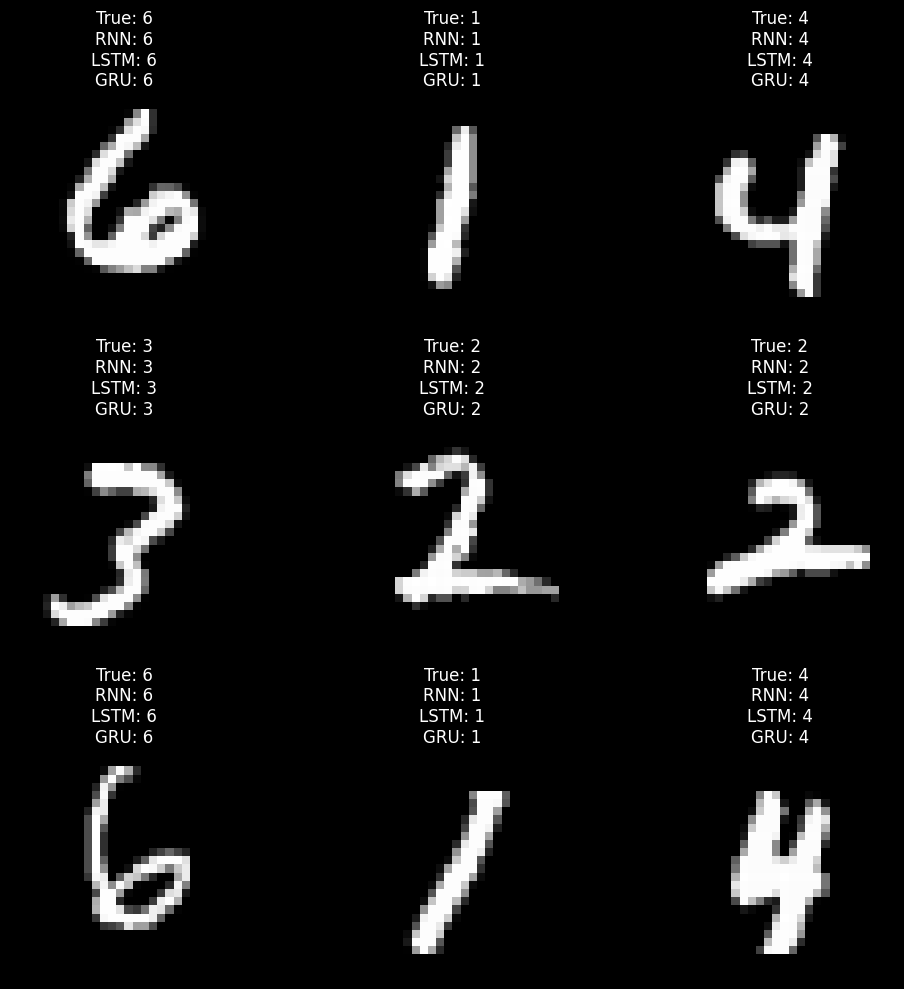

In [17]:
# plot 3 x 3 grid of example from test label + pred
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        idx = np.random.randint(X_test.shape[0])
        axes[i, j].imshow(X_test[idx], cmap='gray')
        true_label = y_test[idx]
        pred_label_rnn = np.argmax(pred_rnn[idx])
        pred_label_lstm = np.argmax(pred_lstm[idx])
        pred_label_gru = np.argmax(pred_gru[idx])
        axes[i, j].set_title(f'True: {true_label}\nRNN: {pred_label_rnn}\nLSTM: {pred_label_lstm}\nGRU: {pred_label_gru}')
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [18]:
# load the simple CNN model from the previous notebook and test it on the same test set
model_cnn = keras.models.load_model('mnist_cnn_model.h5')

In [19]:
# test the CNN model
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test)
print(f'CNN Test accuracy: {test_acc_cnn:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9906 - loss: 0.0305
CNN Test accuracy: 0.9906


In [20]:
# compare where CNN is better than RNN, LSTM and GRU by plotting the misclassified samples for each model
# compare where the RNN, LSTM and GRU are better than CNN by plotting the misclassified samples for each model
pred_cnn = model_cnn.predict(X_test)
misclassified_cnn = np.where(np.argmax(pred_cnn, axis=1) != y_test)[0]
misclassified_rnn = np.where(np.argmax(pred_rnn, axis=1) != y_test)[0]
misclassified_lstm = np.where(np.argmax(pred_lstm, axis=1) != y_test)[0]
misclassified_gru = np.where(np.argmax(pred_gru, axis=1) != y_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


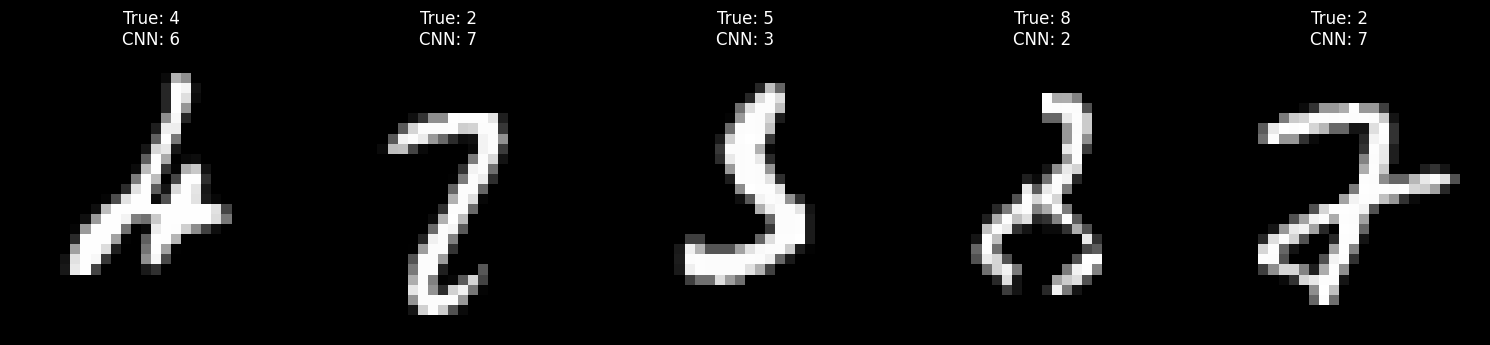

In [21]:
# plot misclassified samples for CNN
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_cnn[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label_cnn = np.argmax(pred_cnn[idx])
    axes[i].set_title(f'True: {true_label}\nCNN: {pred_label_cnn}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

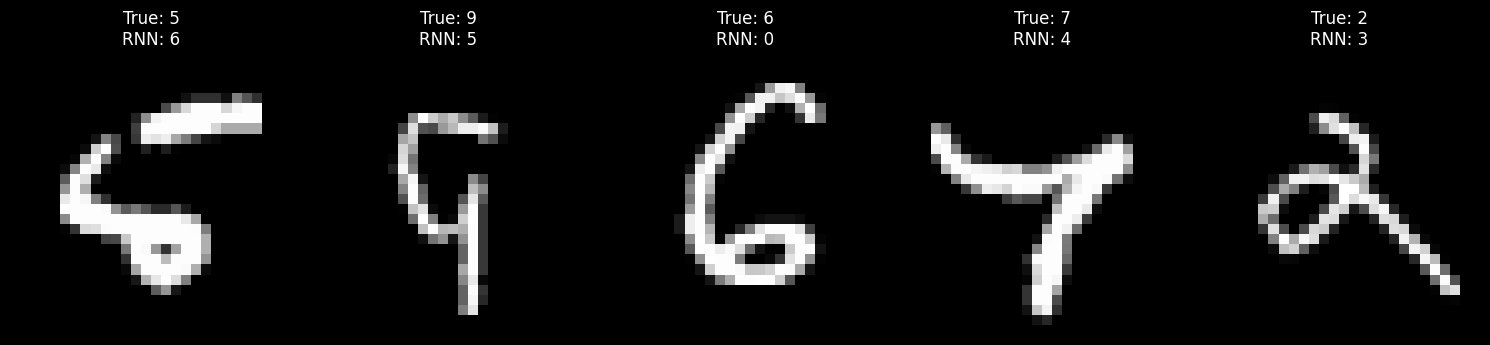

In [22]:
# plot misclassified samples for RNN
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_rnn[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label_rnn = np.argmax(pred_rnn[idx])
    axes[i].set_title(f'True: {true_label}\nRNN: {pred_label_rnn}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

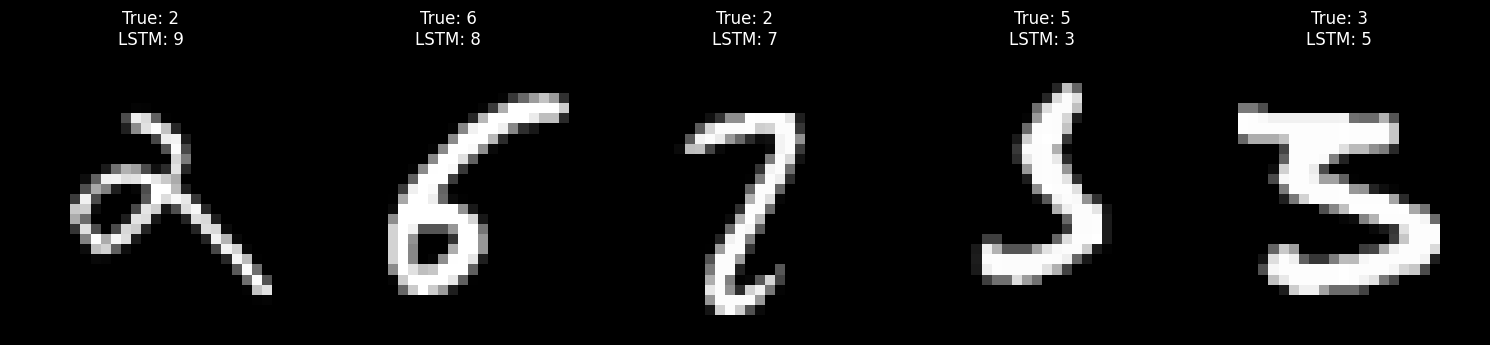

In [23]:
# plot misclassified samples for LSTM
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_lstm[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label_lstm = np.argmax(pred_lstm[idx])
    axes[i].set_title(f'True: {true_label}\nLSTM: {pred_label_lstm}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

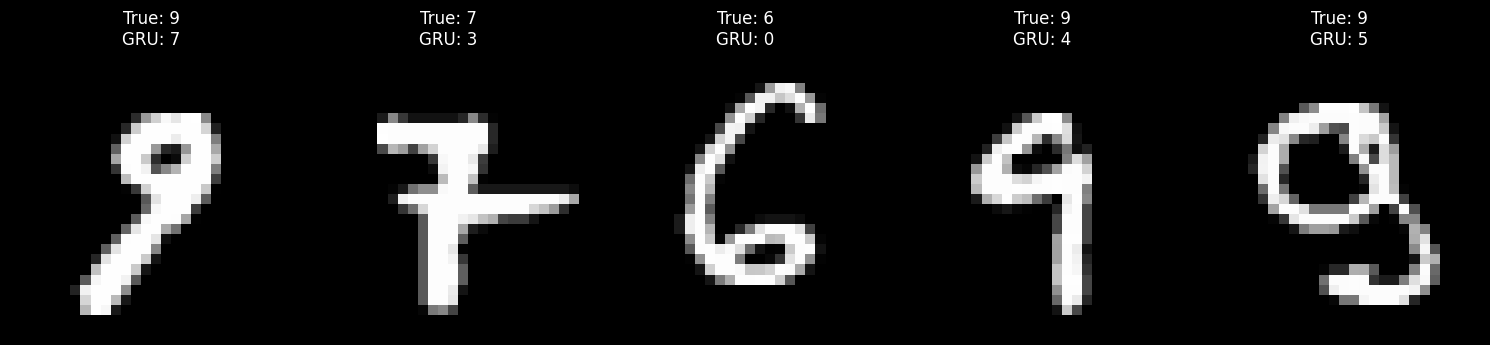

In [24]:
# plot the misclassified samples for GRU
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_gru[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label_gru = np.argmax(pred_gru[idx])
    axes[i].set_title(f'True: {true_label}\nGRU: {pred_label_gru}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [25]:
# save all models to file
model_rnn.save('mnist_rnn_model.h5')
model_lstm.save('mnist_lstm_model.h5')
model_gru.save('mnist_gru_model.h5')